# ECDF in R

In [9]:
options(repr.plot.width = 20, repr.plot.height = 8)

Righe: 5190 
Media: 79.21773 
Mediana: 36 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00   23.00   36.00   79.22   64.00 3506.00 

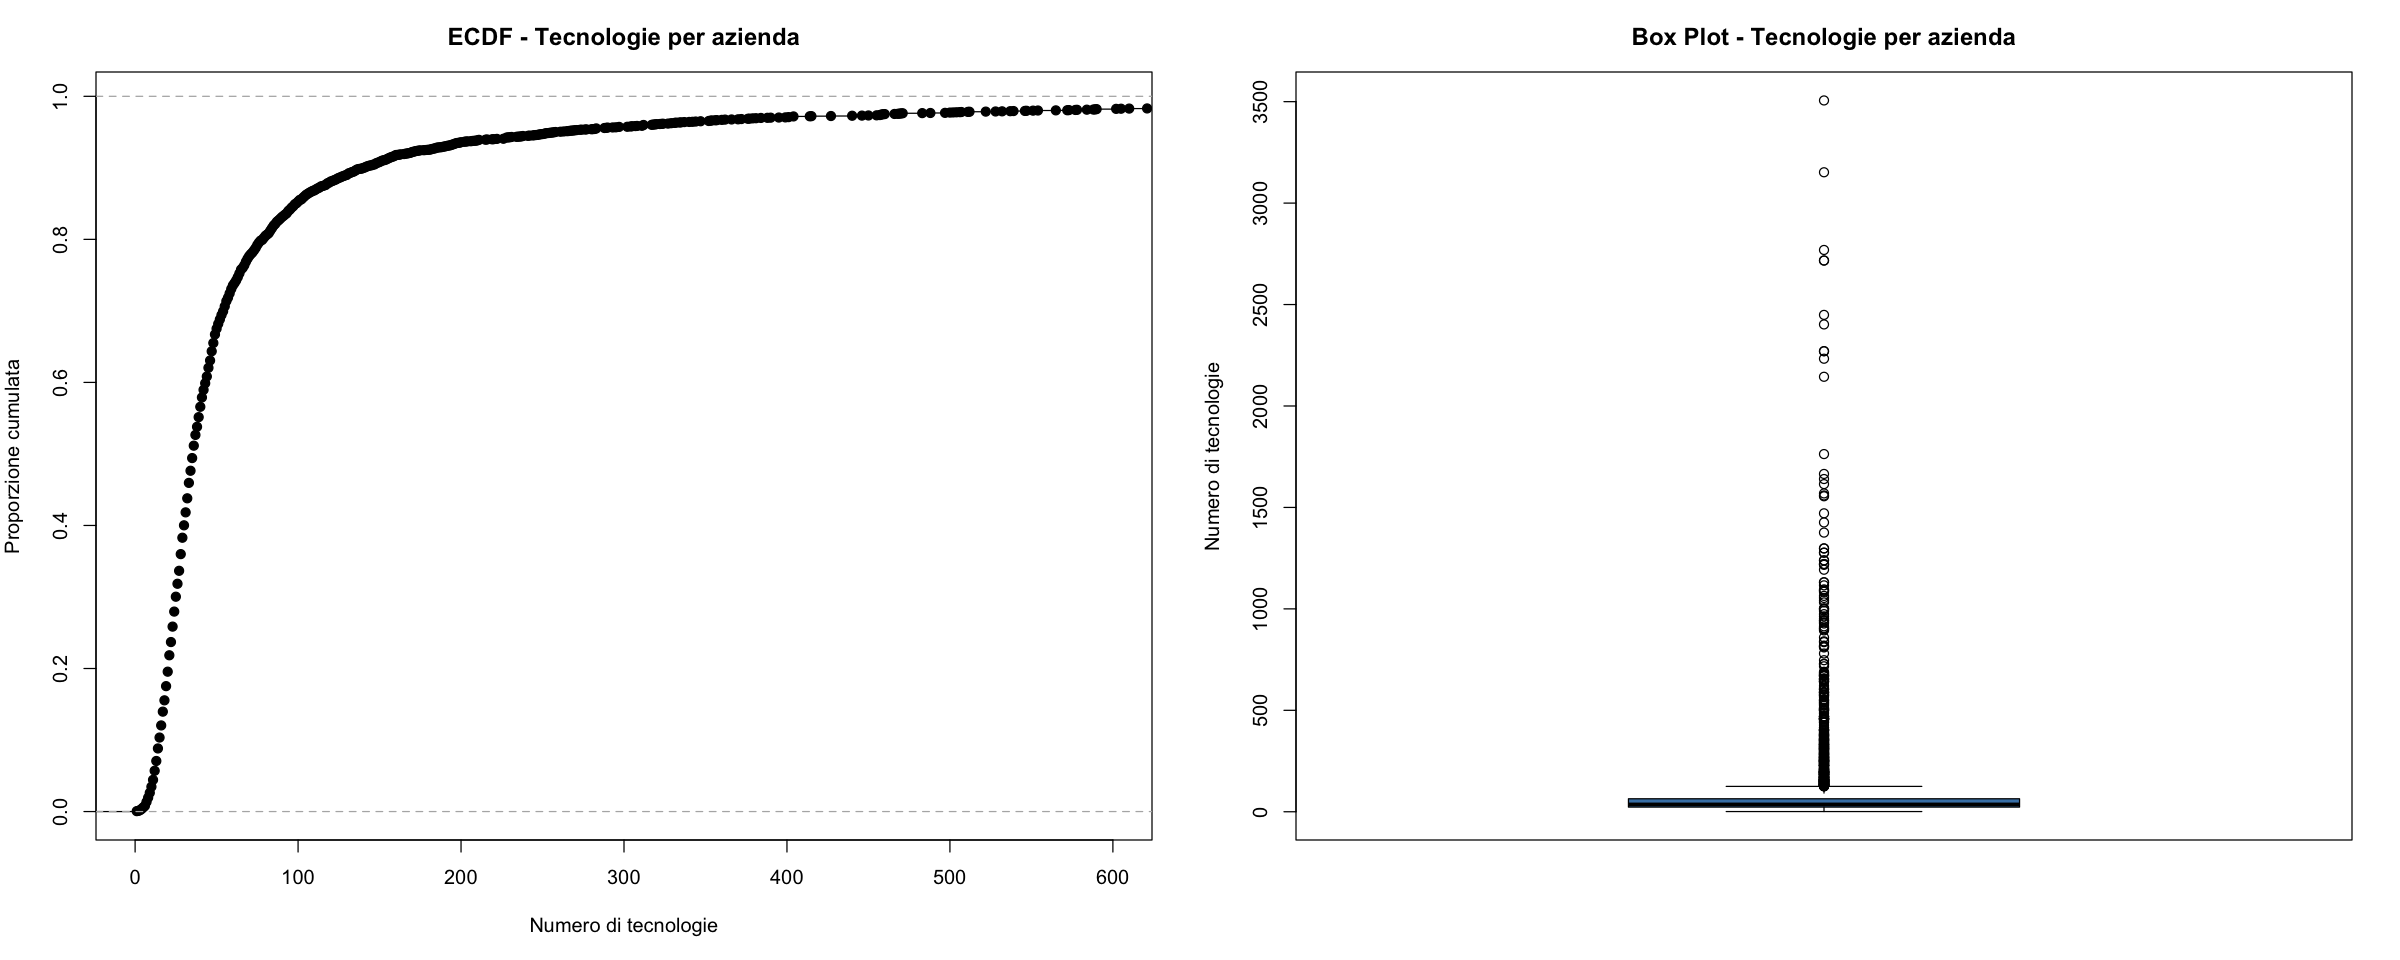

In [11]:
# --- Carica e unisci i due file ---
df <- read.csv("/Users/dmk6603/Documents/ransom_victims/6-main/data/data_tech_swdb.csv", stringsAsFactors = FALSE)

# --- Conta tecnologie per azienda ---
library(jsonlite)
df$tech_count <- sapply(df$technologies, function(t) {
  tryCatch(nrow(fromJSON(t)), error = function(e) 0)
})

# --- Statistiche ---
cat("Righe:", nrow(df), "\n")
cat("Media:", mean(df$tech_count), "\n")
cat("Mediana:", median(df$tech_count), "\n")
summary(df$tech_count)

# --- Plot ---
par(mfrow = c(1, 2), mar = c(5, 4, 3, 2))

# adding xlim to the ECDF plot
plot(ecdf(df$tech_count),
     main = "ECDF - Tecnologie per azienda",
     xlab = "Numero di tecnologie",
     ylab = "Proporzione cumulata",
     xlim = c(0, 600))

boxplot(df$tech_count,
        main = "Box Plot - Tecnologie per azienda",
        ylab = "Numero di tecnologie",
        col = "steelblue")
